# Data Preprocessing & Vectorizer Comparison
## Install & Import

In [1]:
import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import re
import unicodedata
import html

from langdetect import detect
import spacy
from gensim.models.phrases import Phrases, Phraser

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

## Load & Inspect

In [2]:
# Download latest version of the data set
path = kagglehub.dataset_download("sumitm004/reddit-raskscience-flair-dataset")

In [3]:
# Load data (relevant columns only)
df = pd.read_csv(f"{path}/flair_data.csv", usecols=[0, 1, 4, 5, 6, 7, 9, 10, 12])
df.head()

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,NaN,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09


In [4]:
# Inspect data
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df.info())
print()
print(df.describe())

(612668, 9)

['id', 'author', 'question', 'link_flair_css_class', 'link_flair_text', 'description', 'created_utc', 'year', 'retrieved_on']

<class 'pandas.DataFrame'>
RangeIndex: 612668 entries, 0 to 612667
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    612668 non-null  str  
 1   author                612668 non-null  str  
 2   question              612668 non-null  str  
 3   link_flair_css_class  612668 non-null  str  
 4   link_flair_text       612668 non-null  str  
 5   description           594447 non-null  str  
 6   created_utc           612668 non-null  str  
 7   year                  612668 non-null  int64
 8   retrieved_on          612668 non-null  str  
dtypes: int64(1), str(8)
memory usage: 42.1 MB
None

                year
count  612668.000000
mean     2018.690172
std         1.905706
min      2016.000000
25%      2017.000000
50%      2019.000000
75%      20

## Saving Raw Data

In [5]:
# Save lemmatized df to pickle file
df.to_pickle("data/raw_data.pkl")

## Data Quality Assessment
The data set is examined with respect to missing or duplicate values <br>
### Handling Missing Values

In [6]:
# List the number of missing values per column
df.isnull().sum()

id                          0
author                      0
question                    0
link_flair_css_class        0
link_flair_text             0
description             18221
created_utc                 0
year                        0
retrieved_on                0
dtype: int64

In [7]:
df['description'] = df['description'].fillna("")
df.isna().sum()

id                      0
author                  0
question                0
link_flair_css_class    0
link_flair_text         0
description             0
created_utc             0
year                    0
retrieved_on            0
dtype: int64

No completely missing values. Some posts don't have a description. Filling in an empty string will get the issue handled during preprocessing for NLP.


### Handling Duplicates

In [8]:
df[['question', 'description', 'author']].duplicated().sum()

np.int64(6093)

In [9]:
df[df[['question', 'description', 'author']].duplicated()].head(10)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
95,4r8bju,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:42:55,2016,2016-09-03 18:05:47
133,4rchtp,[deleted],What's the physics behind this rainbow paper h...,physics,Physics,[removed],2016-07-05 12:45:50,2016,2016-09-03 18:41:59
421,4qxojf,Khovansky,How do Helmet shells form?,bio,Biology,[removed],2016-07-02 15:38:11,2016,2016-09-02 17:01:24
1114,4vixxa,psycommander,"Are silicon ingots, wafers, and IC dies, huge ...",chem,Chemistry,"Because in these kind of silicon structures, a...",2016-07-31 20:47:28,2016,2016-09-04 16:08:52
1227,4tx89f,[deleted],How do we know what the bee population is arou...,bio,Biology,[removed],2016-07-21 14:27:58,2016,2016-09-04 07:57:13
1409,4s130e,hatrickpatrick,Is this infographic about body language and pe...,psych,Psychology,[removed],2016-07-09 16:46:06,2016,2016-09-03 22:13:42
5645,4wsz96,deathking16132,Photon Time?,astro,Astronomy,[removed],2016-08-08 22:45:54,2016,2016-09-04 22:46:03
6100,4zzajh,[deleted],A few questions about clouds?,astro,Astronomy,[removed],2016-08-28 13:04:41,2016,2016-09-05 14:56:14
6783,4cxvy9,[deleted],What plant is this?,bio,Biology,[removed],2016-04-01 20:25:25,2016,2016-05-17 19:39:55
7175,4c8gsj,[deleted],Why do cars make a loud wooshing sound when on...,physics,Physics,[removed],2016-03-28 02:50:18,2016,2016-05-17 16:19:43


Entries with duplicated question, description, and author are dropped to remove duplicated entries from the data set. This step will be repeated after preprocessing to capture and remove reposts by the same author, taking into account the columns *question_tokens*, *desc_tokens*, and *author* which will be created during preprocessing for NLP.

In [10]:
df = df.drop_duplicates(subset=['question', 'description', 'author'])
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09
...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26


## Exploration & Summary
The data set contains 606,575 Reddit posts published in r/askScience between 2016 and 2022. To get a quick overview, the distribution of posts across css_classes is examined. The column *link_flair_css_class* seems to correspond to a high level classification of academic disciplines. <br>
### Colors, Styles & Presets

In [2]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')

### Distribution across Categories

In [12]:
len(df['link_flair_css_class'].unique().tolist())

16

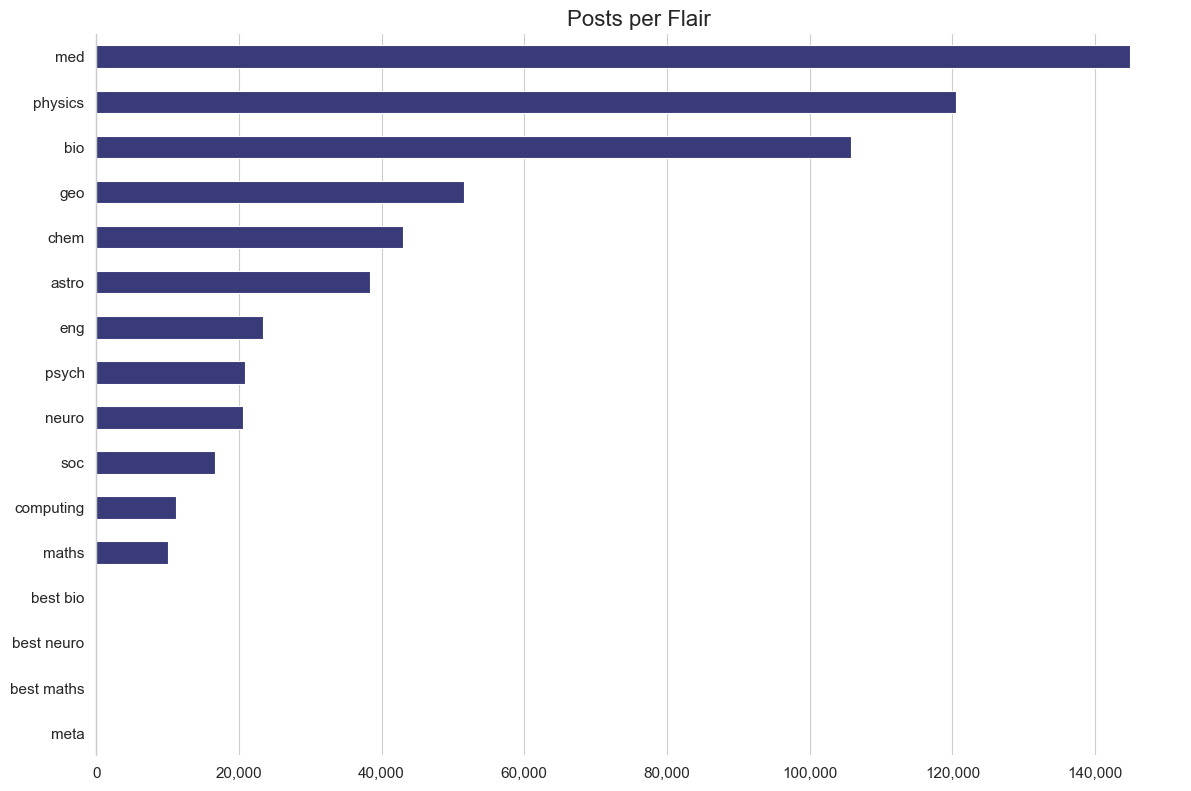

In [ ]:
counts = df["link_flair_css_class"].value_counts()
counts = counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10,8))
counts.plot(kind="barh", ax=ax, colormap='tab20b')

plt.xlabel("")
plt.ylabel("")
plt.title("Posts per Flair", fontsize=16)
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Hide horizontal gridlines
plt.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig('viz/EDA_posts_per_flair.png', dpi=300)
plt.show()

In [14]:
counts.sort_values(ascending=False)

link_flair_css_class
med           144820
physics       120508
bio           105754
geo            51540
chem           43008
astro          38409
eng            23315
psych          20827
neuro          20552
soc            16621
computing      11125
maths          10091
best bio           2
best maths         1
best neuro         1
meta               1
Name: count, dtype: int64

The bar chart shows that medicine, physics and biology are by far the most asked scientific disciplines. The categories *meta* and *best ...* each contain only one post. It is not fully clear what these classes are, presumably platform artifacts indicating posts with high upvotes or similar.

## Cleaning & Preprocessing for NLP

In [15]:
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09
...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26


### Language Detection
Only posts in English are kept for further analysis.

In [16]:
df["org_post"] = (
    df["question"].fillna("").str.strip()
    + " "
    + df["description"].fillna("").str.strip()
).str.strip()

In [17]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Create a new column with detected language
df["language"] = df["org_post"].apply(detect_language)
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en
...,...,...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44,Dentists! I've got a question for you: why do ...,en
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52,Why did we evolve to have consciousness? [remo...,en
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22,Why don't the oceans get saltier over time? Or...,en
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26,Would tracing paper be classed as translucent ...,en


In [18]:
df['language'].value_counts()

language
en         600602
da           1440
fr            790
no            662
af            579
sl            423
it            347
ca            274
nl            233
es            181
vi            146
pt            123
ro             82
sk             77
th             68
de             66
et             65
cy             55
ar             48
sv             30
tr             29
bn             26
id             25
hr             23
tl             23
hi             23
ru             21
so             16
cs             10
pl             10
ko              9
fi              8
unknown         8
fa              8
uk              6
sq              5
lt              4
lv              4
te              4
zh-cn           4
el              4
bg              3
ta              3
hu              2
ur              2
ja              1
ne              1
sw              1
ml              1
Name: count, dtype: int64

In [19]:
# Keep english posts only
df = df[df["language"] == "en"].copy()
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en
...,...,...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44,Dentists! I've got a question for you: why do ...,en
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52,Why did we evolve to have consciousness? [remo...,en
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22,Why don't the oceans get saltier over time? Or...,en
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26,Would tracing paper be classed as translucent ...,en


### Basic Cleaning of Question and Description
The columns *question* and *description* comprise the full content of the Reddit post. Both columns are cleaned individually and combined at a later stage in preprocessing. Cleaning includes lowercasing, removal or html and Reddit artifacts, URLs and mentions, punctuation removal, whitespace normalization.

In [20]:
def basic_clean(text):
    if not isinstance(text, str):
        return text

    # Lowercase
    text = text.lower()

    # Normalize Unicode
    text = unicodedata.normalize("NFKC", text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove elongations
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Reddit mentions
    text = re.sub(r"/u/\w+|/r/\w+", "", text)

    # Replace newlines + tabs with space
    text = re.sub(r"[\n\r\t]+", " ", text)

    # Remove leftover HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Replace punctuation with whitespace
    text = re.sub(r"[^\w\s-]", " ", text)

    # Replace multiple dashes or underscores
    text = re.sub(r"[-_]{2,}", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_question"] = df["question"].apply(basic_clean)
df['clean_desc'] = df['description'].apply(basic_clean)
df.head(10)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed
5,4r18ga,Mitzuiro,"Why are there so many ""accident"" babies yet so...",bio,Biology,[removed],2016-07-03 08:19:16,2016,2016-09-02 17:33:59,"Why are there so many ""accident"" babies yet so...",en,why are there so many accident babies yet so m...,removed
6,4r15kv,SexyBigEyebrowz,I understand how time dialates when we speed u...,physics,Physics,[removed],2016-07-03 07:44:19,2016,2016-09-02 17:33:20,I understand how time dialates when we speed u...,en,i understand how time dialates when we speed u...,removed
7,4r13on,[deleted],Could a colonised Mars be shielded from the Su...,geo,Planetary Sci.,[removed],2016-07-03 07:22:21,2016,2016-09-02 17:32:53,Could a colonised Mars be shielded from the Su...,en,could a colonised mars be shielded from the su...,removed
8,4r13jj,sulfate4,"To hold your breath longer underwater, should ...",med,Human Body,[removed],2016-07-03 07:20:28,2016,2016-09-02 17:32:51,"To hold your breath longer underwater, should ...",en,to hold your breath longer underwater should y...,removed
9,4r11ps,My_Bipolar_Account,Why do so many different psychiatric medicatio...,med,Medicine,[removed],2016-07-03 06:59:31,2016,2016-09-02 17:32:24,Why do so many different psychiatric medicatio...,en,why do so many different psychiatric medicatio...,removed


### Tokenization, Lemmatization & Stopword Removal

In [21]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def clean_doc(doc):
    tokens = []

    for token in doc:

        if token.is_space or token.is_punct:
            continue

        if token.is_stop:
            continue

        lemma = token.lemma_.lower()
        tokens.append(lemma)

    return tokens

docs = nlp.pipe(df["clean_question"].astype(str), batch_size=1000, n_process=-1)
df["question_tokens"] = [clean_doc(doc) for doc in docs]

docs = nlp.pipe(df["clean_desc"].astype(str), batch_size=1000, n_process=-1)
df["desc_tokens"] = [clean_doc(doc) for doc in docs]

df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[remove]
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[remove]
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[]
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[remove]
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[remove]


### Examining Meaningfulness of Short Questions & Descriptions
If question and descriptions are too short, it might happen that they do not carry meaning regarding the actual content of the question. Thus the occurrence frequency of short questions and descriptions is examined.

In [22]:
pd.set_option('display.max_rows', None)

In [23]:
df[
    (df["question_tokens"].str.len() < 2)
]["question_tokens"].value_counts()

question_tokens
[]                                                    146
[happen]                                               71
[universe]                                             62
[help]                                                 49
[space]                                                41
[time]                                                 38
[think]                                                32
[dream]                                                32
[possible]                                             32
[question]                                             30
[explain]                                              28
[light]                                                25
[consciousness]                                        24
[energy]                                               24
[vaccine]                                              23
[gravity]                                              22
[work]                                                 2

In [24]:
df[
    (df["desc_tokens"].str.len() < 3)
]["desc_tokens"].value_counts()

desc_tokens
[remove]                       557970
[]                              17709
[delete]                         1493
[title]                            41
[title, say]                       14
[thank]                            13
[curious]                           9
[thank, advance]                    7
[example]                           6
[basically, title]                  4
[like]                              4
[m, talk]                           3
[physics]                           3
[look, like]                        3
[biology]                           3
[source]                            3
[pretty, title]                     3
[calculate]                         2
[picture]                           2
[know]                              2
[engineering]                       2
[happen]                            2
[earth, science]                    2
[link]                              2
[edit, thank]                       2
[human]                             2


The subreddit r/askScience asks users to put their acutal question into the field 'question' when creating a post. The field 'description' is used to provide further information, examples or backgrounds. From the values above it can be seen that short question tend to state the overall topic or a central key word of the question. These tokens should be kept for analysis. The short descriptions on the other hand also contain platform artifacs (removed/ deleted posts) or social artifacts ('thanks in advance'/ 'just curious') which do not add value to the content of the question. Thus, questions of all lengths will be kept but descriptions with less than three words and more than three occurences will be removed to reduce noise.

In [ ]:
desc_counts = df["desc_tokens"].value_counts()

bad_tokens = [
    seq for seq, count in desc_counts.items()
    if isinstance(seq, list) and len(seq) < 3 and count > 3
]

# Replace bad_tokens with an empty list in desc_tokens
df["desc_tokens"] = df["desc_tokens"].apply(
    lambda x: [] if isinstance(x, list) and len(x) < 3 and tuple(x) in [tuple(seq) for seq in bad_tokens] else x
)

print("Bad tokens:", bad_tokens)
df.head(5)

Bad tokens: [['remove'], [], ['delete'], ['title'], ['title', 'say'], ['thank'], ['curious'], ['thank', 'advance'], ['example'], ['basically', 'title'], ['like']]


,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[]
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[]
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[]
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[]
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[]


### Checking for Duplicates Again
Posts with the same tokens for *question* and *description*, and the same *author* are dropped.

In [27]:
df["q_tuple"] = df["question_tokens"].apply(tuple)
df["d_tuple"] = df["desc_tokens"].apply(tuple)

df[['q_tuple', 'd_tuple', 'author']].duplicated().sum()

np.int64(9424)

In [28]:
df = df.drop_duplicates(subset=["q_tuple", "d_tuple", "author"])
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",()
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",()
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",()
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",()
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",()


### Concatenate Question & Description Tokens

In [29]:
df['post_tokens'] = df['question_tokens'] + df['desc_tokens']
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


## Detect Bigrams

In [30]:
from gensim.models.phrases import Phrases, Phraser

# Detect and apply bigrams
phrases = Phrases(df['post_tokens'], min_count=5, threshold=10)
bigram = Phraser(phrases)
df['post_tokens'] = [bigram[doc] for doc in df['post_tokens']]

# Join tokens for vectorization
df['clean_text'] = [" ".join(doc) for doc in df['post_tokens']]

# Print detected bigrams and their counts
bigram_phrases = phrases.export_phrases()
for item in bigram_phrases:
    print(item)

df.head(5)

big_bang
scientific_explanation
research_project
speed_light
atmosphere_strip
hold_breath
psychiatric_medication
weight_gain
pinpoint_location
tendon_ligament
protein_fold
terraform_mar
laser_propel
highly_reflective
solar_sail
general_relativity
relativity_quantum
quantum_mechanic
omega_3
scientific_reasoning
year_old
interstellar_space
frame_reference
isn_t
m_concerned
relaxed_state
accurately_describe
brain_damage
prove_wrong
taste_well
ice_cream
single_celle
celle_organism
reduce_chance
pear_shape
perception_time
scientific_community
tl_dr
steady_state
bang_theory
bright_light
camera_lens
quark_antiquark
antiquark_pair
don_t
tall_building
magnus_effect
electromagnetic_radiation
reach_destination
planck_length
man_woman
radioactive_element
neutron_star
hi_guy
mind_blow
approach_speed
hit_ground
15_year
10_gram
pear_shaped
atomic_nucleus
unanswered_question
atomic_structure
standard_deviation
electron_orbital
quantum_computing
nuclear_power
1_2
build_muscle
penis_enlargement
doesn_t


,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


## Save Preprocessed Data

In [3]:
# Save lemmatized df to pickle file
df.to_pickle("data/preprocessed_data.pkl")

NameError: name 'df' is not defined

## Vectorizer Comparison

In [4]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


In [5]:
# BoW
bow = CountVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8
)
X_bow = bow.fit_transform(df['clean_text'])

# TFIDF
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8
)
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Compare documents
for doc_id in range(11):

    bow_df = pd.DataFrame(
        X_bow[doc_id].toarray(),
        columns=bow.get_feature_names_out()
    ).T

    tfidf_df = pd.DataFrame(
        X_tfidf[doc_id].toarray(),
        columns=tfidf.get_feature_names_out()
    ).T

    comparison = pd.DataFrame({
        'BoW_count': bow_df[0],
        'TFIDF_weight': tfidf_df[0]
    })

    comparison = comparison[
        comparison['BoW_count'] > 0
    ].sort_values('BoW_count', ascending=False)

    print(comparison.head(20))

          BoW_count  TFIDF_weight
big_bang          1      0.614221
define            1      0.686166
time              1      0.389754
                        BoW_count  TFIDF_weight
event                           1      0.381124
good                            1      0.300622
meteorite                       1      0.493019
scientific_explanation          1      0.467372
ufo                             1      0.550333
          BoW_count  TFIDF_weight
commonly          1      0.466446
fact              1      0.383685
gas               1      0.341556
know              1      0.246192
metal             1      0.361353
oxidize           1      0.525151
possible          1      0.227119
           BoW_count  TFIDF_weight
build              1      0.425081
china              1      0.561009
large              1      0.377848
question           1      0.343551
telescope          1      0.493740
                  BoW_count  TFIDF_weight
current                   1      0.314455
decade    

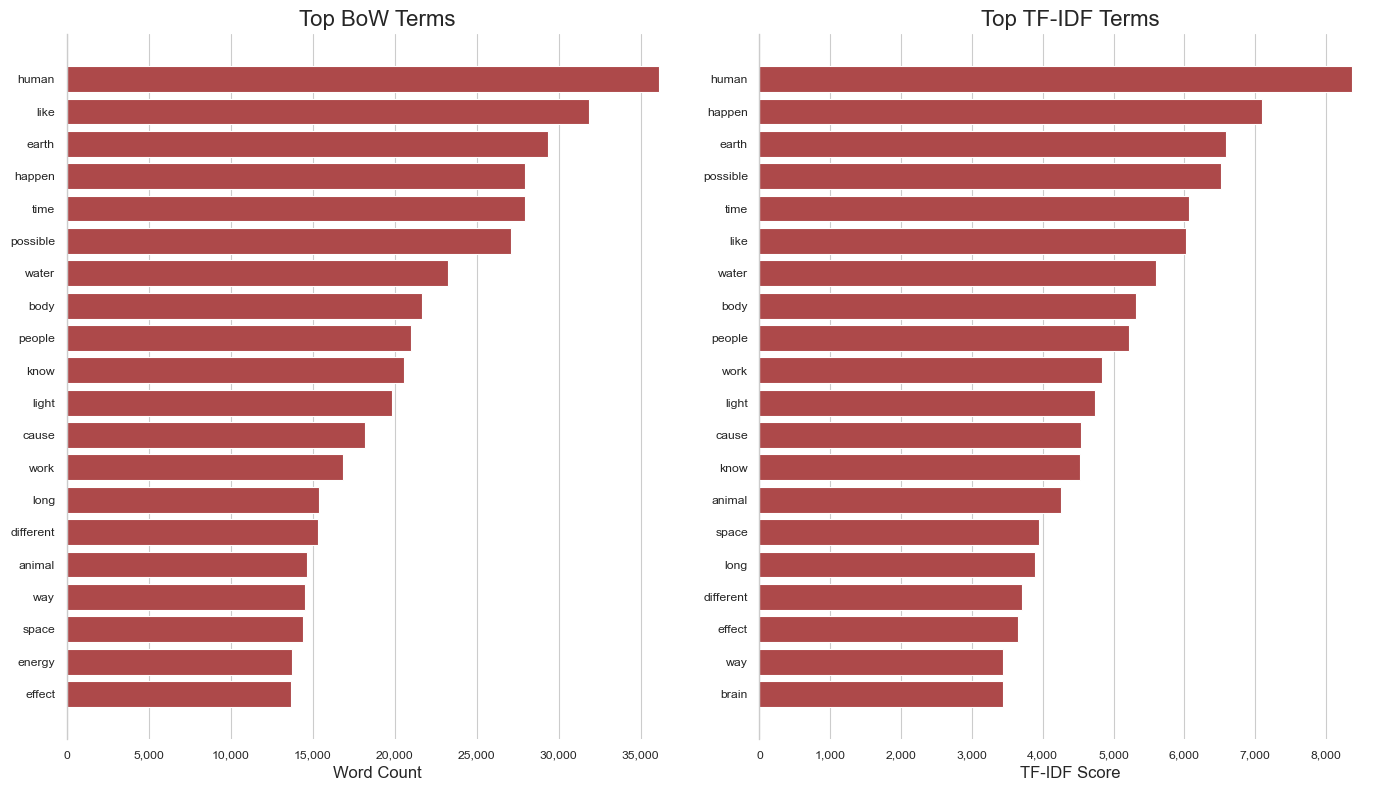

In [6]:
# Aggregate scores
bow_sum = np.array(X_bow.sum(axis=0)).flatten()
tfidf_sum = np.array(X_tfidf.sum(axis=0)).flatten()

# Feature names
bow_terms = bow.get_feature_names_out()
tfidf_terms = tfidf.get_feature_names_out()

# Top 20 indices
bow_top_idx = bow_sum.argsort()[-20:]
tfidf_top_idx = tfidf_sum.argsort()[-20:]

# Define color
color = plt.get_cmap('tab20b')(13)

# Plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 8),
    sharey=False
)

# BoW subplot
axes[0].barh(
    bow_terms[bow_top_idx],
    bow_sum[bow_top_idx],
    color=color
)
axes[0].set_title("Top BoW Terms", fontsize=16)
axes[0].set_xlabel("Word Count", fontsize=12)

# TF-IDF subplot
axes[1].barh(
    tfidf_terms[tfidf_top_idx],
    tfidf_sum[tfidf_top_idx],
    color=color
)
axes[1].set_title("Top TF-IDF Terms", fontsize=16)
axes[1].set_xlabel("TF-IDF Score", fontsize=12)

for ax in axes:
    ax.yaxis.grid(False)


# Format x-axis with commas
for ax in axes:
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Despine manually (matplotlib only)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('viz/Vectorizer_Comparison_top_terms.png', dpi=300)
plt.show()

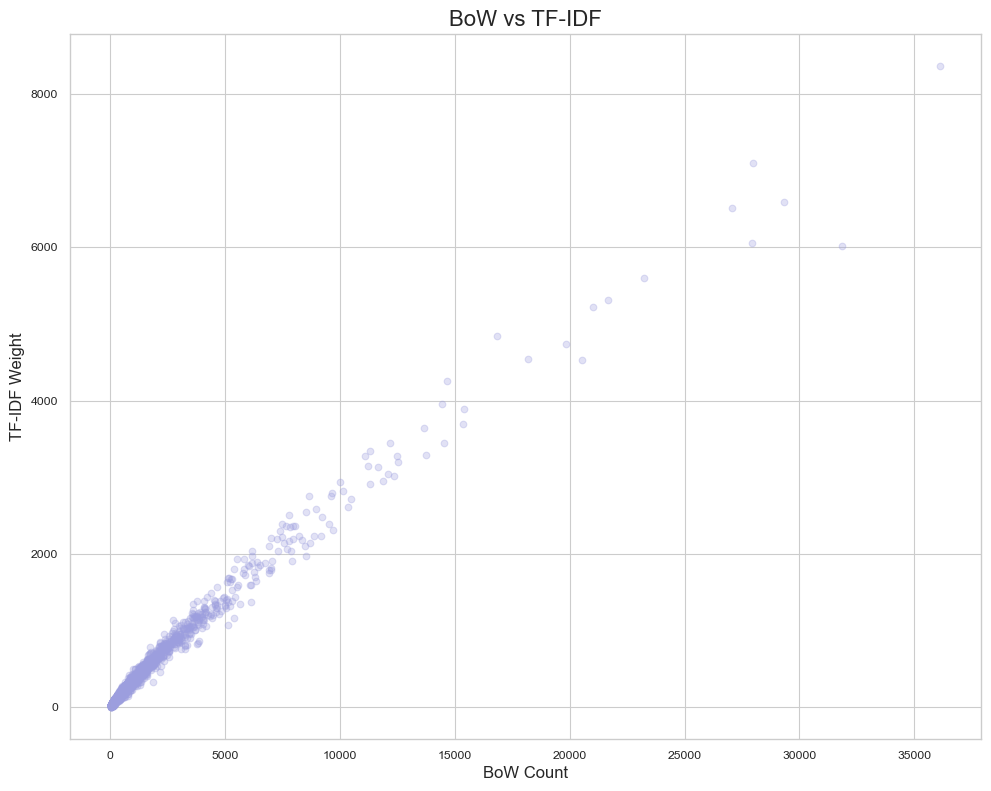

In [7]:
bow_sum = np.array(X_bow.sum(axis=0)).flatten()
tfidf_sum = np.array(X_tfidf.sum(axis=0)).flatten()

color = plt.get_cmap('tab20b')(3)

plt.figure(figsize=(10, 8))
plt.scatter(bow_sum, tfidf_sum, alpha=0.3, color=color)

plt.xlabel("BoW Count", fontsize=12)
plt.ylabel("TF-IDF Weight", fontsize=12)
plt.title("BoW vs TF-IDF", fontsize=16)

plt.tight_layout()

plt.savefig('viz/Vectorizer_Comparison_scatter.png', dpi=300)
plt.show()

The plotted points resemble a straight line. Thus, the scatterplot suggest that BoW and TF-IDF are behaving similarly. This might be due to the preliminary removl or stopwords during preprocessing and overly common words though the paramter *max_df=0.8* during vectorization.

In [8]:
bow_sparsity = 1 - X_bow.nnz / (
    X_bow.shape[0] * X_bow.shape[1]
)

tfidf_sparsity = 1 - X_tfidf.nnz / (
    X_tfidf.shape[0] * X_tfidf.shape[1]
)

print("BoW sparsity:", bow_sparsity)
print("TFIDF sparsity:", tfidf_sparsity)

BoW sparsity: 0.9993878312454118
TFIDF sparsity: 0.9993878312454118


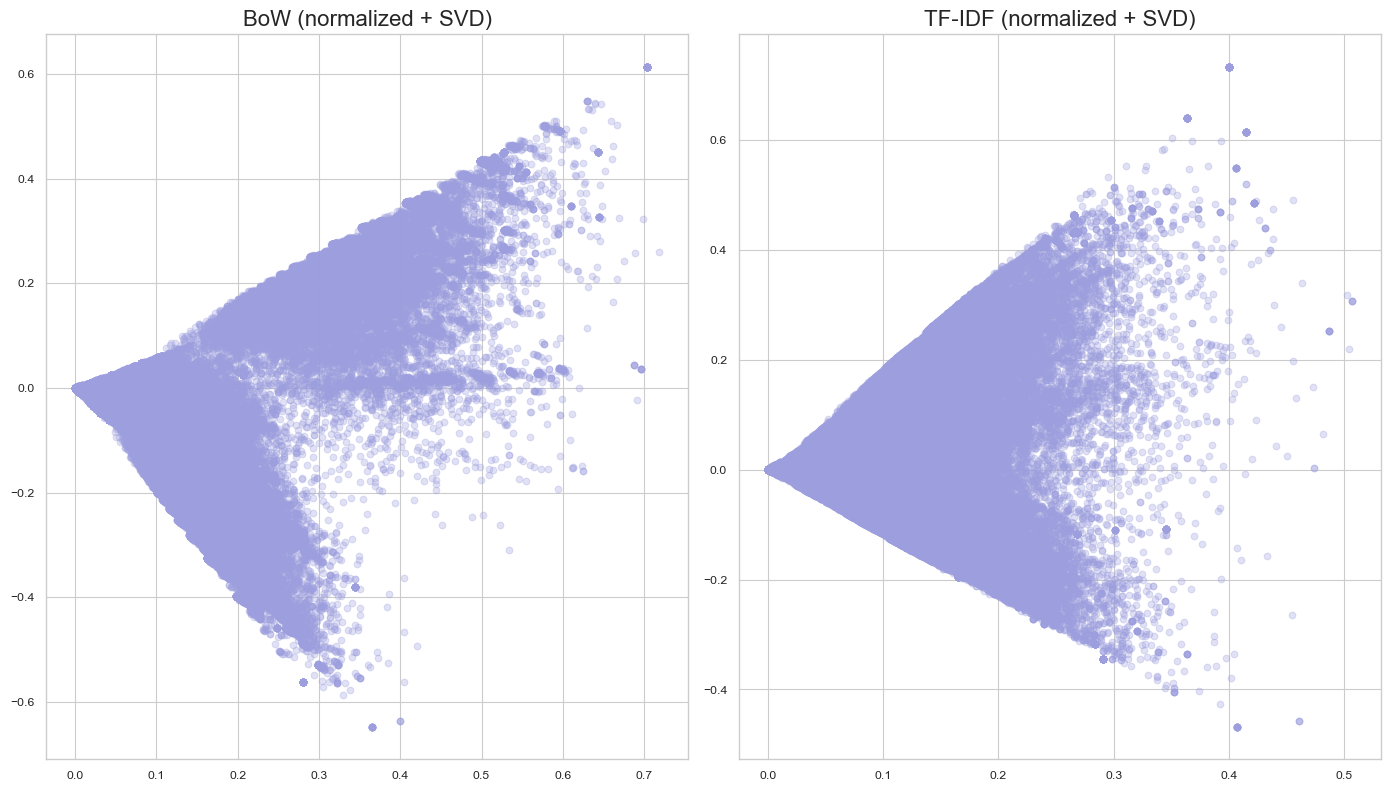

In [9]:
# normalize first (important if comparing geometries)
X_bow_norm = normalize(X_bow)
X_tfidf_norm = normalize(X_tfidf)

svd = TruncatedSVD(n_components=2, random_state=42)

bow_2d = svd.fit_transform(X_bow_norm)
tfidf_2d = svd.fit_transform(X_tfidf_norm)

color = plt.get_cmap('tab20b')(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].scatter(bow_2d[:, 0], bow_2d[:, 1], alpha=0.3, color=color)
axes[0].set_title("BoW (normalized + SVD)", fontsize=16)

axes[1].scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], alpha=0.3, color=color)
axes[1].set_title("TF-IDF (normalized + SVD)", fontsize=16)

plt.tight_layout()
plt.savefig('viz/Vectorizer_Comparison_SVD_projection.png', dpi=300)
plt.show()